In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv(r'netflix_titles.csv')

print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns}')
print(f'\nData Types: {df.dtypes}')
print(f'\nFirst 5 rows: {df.head()}')
print(f'\nNull counts: \n{df.isnull().sum()}')
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Shape: (8807, 12)

Columns: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Data Types: show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

First 5 rows:   show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                 

# Data Cleaning

In [5]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Fill missing values — Pandas 3.0 compatible syntax
df['director'] = df['director'].fillna('Unknown')
df['cast']     = df['cast'].fillna('Unknown')
df['country']  = df['country'].fillna('Unknown')
df['rating']   = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna('Unknown')

# Convert date_added to datetime safely
# Check if already datetime, if not convert
if df['date_added'].dtype != 'datetime64[ns]':
    df['date_added'] = pd.to_datetime(df['date_added'].astype(str).str.strip(), errors='coerce')

df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Extract numeric duration
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

print("After cleaning:")
print("Shape:", df.shape)
print("\nNull counts:\n", df.isnull().sum())
print("\nSample:\n", df[['title','type','release_year','year_added','duration_int']].head())

After cleaning:
Shape: (8807, 15)

Null counts:
 show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      10
month_added     10
duration_int     3
dtype: int64

Sample:
                    title     type  release_year  year_added  duration_int
0   Dick Johnson Is Dead    Movie          2020      2021.0          90.0
1          Blood & Water  TV Show          2021      2021.0           2.0
2              Ganglands  TV Show          2021      2021.0           1.0
3  Jailbirds New Orleans  TV Show          2021      2021.0           1.0
4           Kota Factory  TV Show          2021      2021.0           2.0


# Content Overview

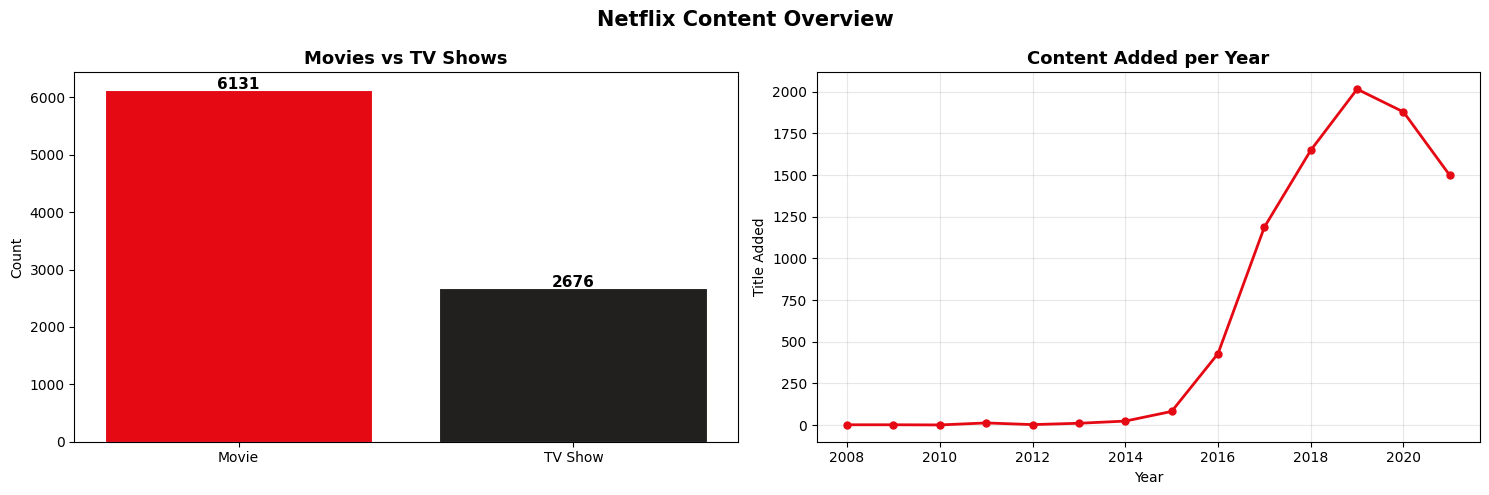

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Netflix Content Overview', fontsize=15, fontweight='bold')

type_counts = df['type'].value_counts()
colors = ['#e50914', '#221f1f']
axes[0].bar(type_counts.index, type_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Movies vs TV Shows', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=11)

yearly = df.groupby('year_added').size().dropna()
axes[1].plot(yearly.index, yearly.values, color='#e50914',
             marker='o', linewidth=2, markersize=5)
axes[1].set_title('Content Added per Year', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Title Added')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('netflix_overview.png', dpi=150, bbox_inches='tight')
plt.show()

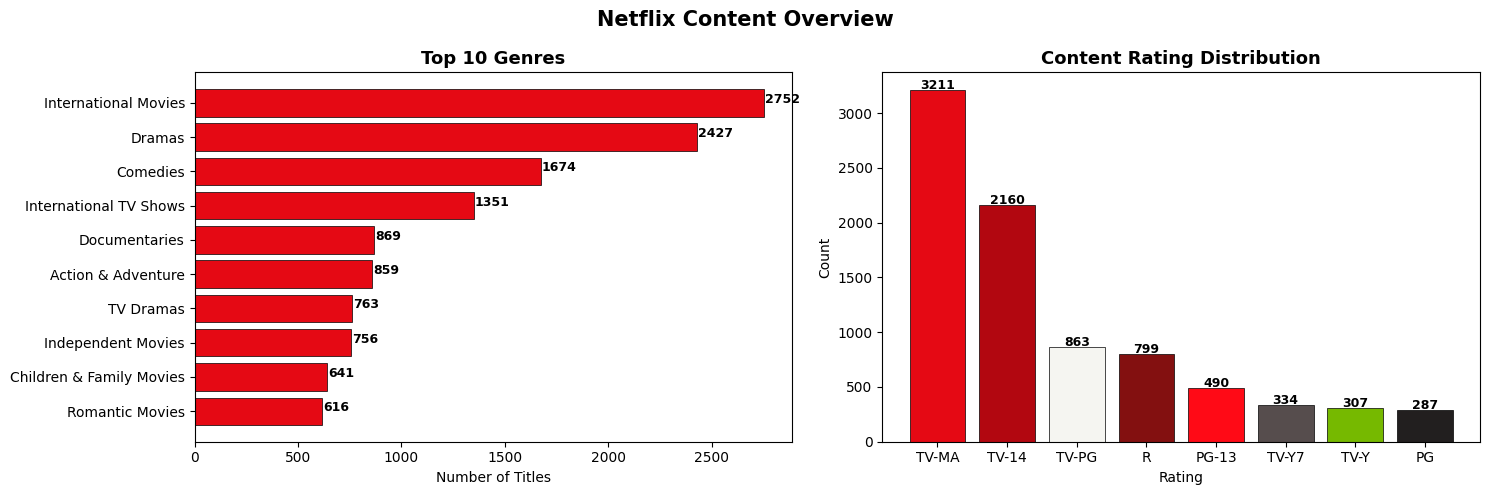

In [10]:
from pygments.formatters.img import FontManager
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Netflix Content Overview', fontsize=15, fontweight='bold')

all_genres = df['listed_in'].str.split(', ').explode()
top_genres = all_genres.value_counts().head(10)

axes[0].barh(top_genres.index[::-1], top_genres.values[::-1],
             color='#e50914', edgecolor='black', linewidth=0.5)
axes[0].set_title('Top 10 Genres', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Titles')
for i, v in enumerate(top_genres.values[::-1]):
    axes[0].text(v + 5, i, str(v), ha='left', fontweight='bold', fontsize=9)

#Rating Distribution
top_ratings = df['rating'].value_counts().head(8)
axes[1].bar(top_ratings.index, top_ratings.values,
            color=['#e50914','#b20710','#f5f5f1','#831010',
                   '#ff0a16','#564d4d','#76b900','#221f1f'],
            edgecolor='black', linewidth=0.5)
axes[1].set_title('Content Rating Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
for i, v in enumerate(top_ratings.values):
  axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('netflix_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Country & Release Year Analysis

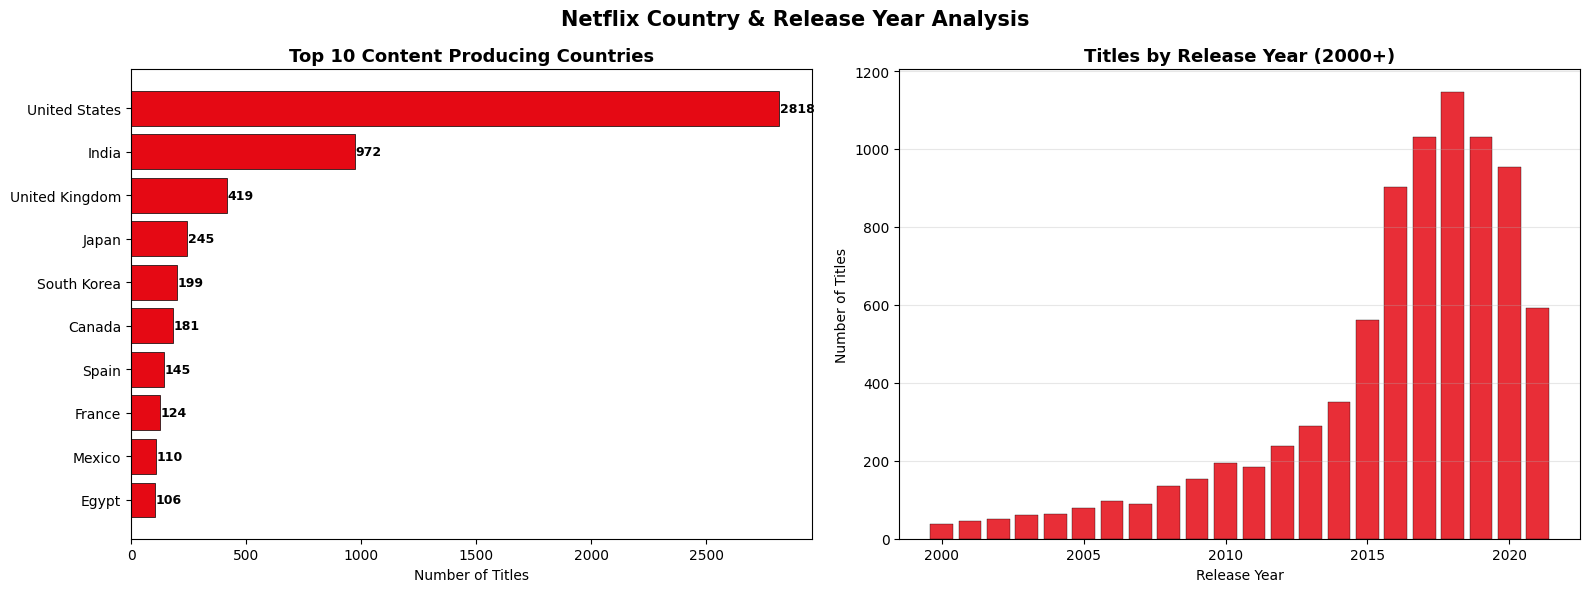

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Netflix Country & Release Year Analysis', fontsize=15, fontweight='bold')

# Top 10 countries
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
axes[0].barh(top_countries.index[::-1], top_countries.values[::-1],
             color='#e50914', edgecolor='black', linewidth=0.5)
axes[0].set_title('Top 10 Content Producing Countries', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Titles')
for i, v in enumerate(top_countries.values[::-1]):
    axes[0].text(v + 2, i, str(v), va='center', fontweight='bold', fontsize=9)

# Release year distribution
release_dist = df['release_year'].value_counts().sort_index()
release_dist = release_dist[release_dist.index >= 2000]
axes[1].bar(release_dist.index, release_dist.values,
            color='#e50914', edgecolor='black', linewidth=0.3, alpha=0.85)
axes[1].set_title('Titles by Release Year (2000+)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Release Year')
axes[1].set_ylabel('Number of Titles')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('netflix_country_year.png', dpi=150, bbox_inches='tight')
plt.show()

# Movie Duration & TV Show Seasons Analysis

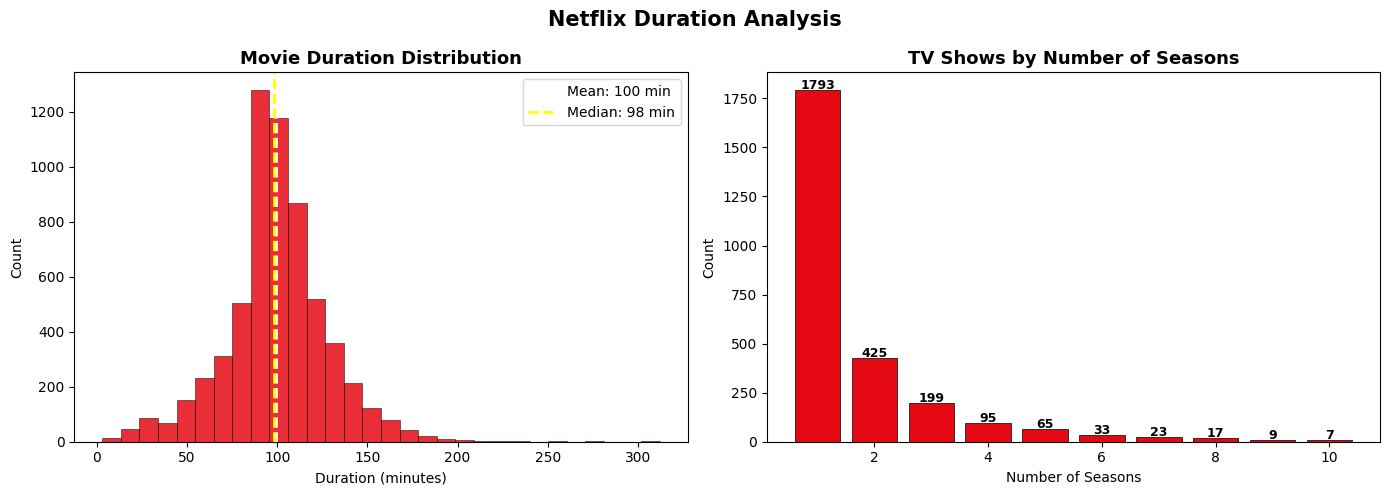

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Netflix Duration Analysis', fontsize=15, fontweight='bold')

# Movie duration distribution
movies = df[df['type'] == 'Movie'].dropna(subset=['duration_int'])
axes[0].hist(movies['duration_int'], bins=30, color='#e50914',
             edgecolor='black', linewidth=0.4, alpha=0.85)
axes[0].axvline(movies['duration_int'].mean(), color='white',
                linestyle='--', linewidth=2,
                label=f"Mean: {movies['duration_int'].mean():.0f} min")
axes[0].axvline(movies['duration_int'].median(), color='yellow',
                linestyle='--', linewidth=2,
                label=f"Median: {movies['duration_int'].median():.0f} min")
axes[0].set_title('Movie Duration Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Count')
axes[0].legend()

# TV Show seasons distribution
shows = df[df['type'] == 'TV Show'].dropna(subset=['duration_int'])
season_counts = shows['duration_int'].value_counts().sort_index().head(10)
axes[1].bar(season_counts.index.astype(int), season_counts.values,
            color='#e50914', edgecolor='black', linewidth=0.5)
axes[1].set_title('TV Shows by Number of Seasons', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Seasons')
axes[1].set_ylabel('Count')
for i, (k, v) in enumerate(season_counts.items()):
    axes[1].text(k, v + 5, str(v), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('netflix_duration.png', dpi=150, bbox_inches='tight')
plt.show()

#  Key Insights Summary (NumPy Stats)

In [20]:
print('=' * 55)
print('        NETFLIX DATASET — KEY INSIGHTS SUMMARY')
print('=' * 55)

total_len = len(df)
movie_count = len(df[df['type'] == 'Movie'])
shows_count = len(df[df['type'] == 'TV Show'])

print(f'\nTotal Titles: {total_len}')
print(f'\nMovies: {movie_count} ({movie_count / total_len*100:.1f}%)')
print(f'\nTV Shows: {shows_count} ({shows_count / total_len*100:.1f}%)')

print(f'\nTop Country: {top_countries.index[0]} ({top_countries.values[0]} titles)')
print(f'\nTop Release Year: {release_dist.index[0]} ({release_dist.values[0]})')
print(f'\nTop Genre: {top_genres.index[0]} ({top_genres.values[0]} titles)')

print(f'\nMovie Duration')
print(f'\nMean: {movies['duration_int'].mean():.1f} min')
print(f'\nMedian: {movies['duration_int'].median():.1f} min')
print(f'\nStd: {movies['duration_int'].std():.1f} min')
print(f'\nMin: {movies['duration_int'].min():.1f} min')
print(f'\nMax: {movies['duration_int'].max():.1f} min')

print(f'\nContent Release Year')
print(f'\nOldest: {int(df['release_year'].min())}')
print(f'Newest: {int(df['release_year'].max())}')
print(f'Most Content from: {int(df['release_year'].mode()[0])}')

print(f"\nPeak year for additions: {int(yearly.idxmax())} ({int(yearly.max())} titles)")
print("=" * 55)

        NETFLIX DATASET — KEY INSIGHTS SUMMARY

Total Titles: 8807

Movies: 6131 (69.6%)

TV Shows: 2676 (30.4%)

Top Country: United States (2818 titles)

Top Release Year: 2000 (37)

Top Genre: International Movies (2752 titles)

Movie Duration

Mean: 99.6 min

Median: 98.0 min

Std: 28.3 min

Min: 3.0 min

Max: 312.0 min

Content Release Year

Oldest: 1925
Newest: 2021
Most Content from: 2018

Peak year for additions: 2019 (2016 titles)
